# Run infection dynamics with monoclonal killer T cell response

In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy import stats
import os
import seaborn as sns
from stoch_sim_model import *
from optimize_nets import *

plt.style.use('custom.mplstyle')
# %config InlineBackend.figure_format = 'retina'
%load_ext line_profiler

In [2]:
avg_sim_time = 2.5/(60*60) # 1.6/(60*60)

print('full-reg:',(len(psi_2d_nobias)**4)*len(infection_sample_select),
      np.ceil((len(psi_2d_nobias)**4*len(infection_sample_select))/(num_cpu*run_time/avg_sim_time)), 
      str(int(1.0/avg_sim_time)) + ' jobs per cpu per hour')

print('prim-Nact-Ediv:',len(psi_2d)*len(psi_2d)*len(infection_sample_select), 
      np.ceil((len(psi_2d)*len(psi_2d)*len(infection_sample_select))/(num_cpu*run_time/avg_sim_time)), 
      str(int(1.0/avg_sim_time)) + ' jobs per cpu per hour')

print('auto-sparse-reg:',len(psi_2d_sparse)*len(auto_sample), 
      np.ceil((len(psi_2d_sparse)*len(auto_sample))/(num_cpu*run_time/avg_sim_time)), 
      str(int(1.0/avg_sim_time)) + ' jobs per cpu per hour')

print('cancer-sparse-reg:',len(psi_2d_sparse)*len(cancer_sample), 
      np.ceil((len(psi_2d_sparse)*len(cancer_sample))/(num_cpu*run_time/avg_sim_time)), 
      str(int(1.0/avg_sim_time)) + ' jobs per cpu per hour')

print('sparse-reg:', len(psi_2d_sparse)*len(infection_sample_select),
      np.ceil(len(psi_2d_sparse)*len(infection_sample_select)/(num_cpu*run_time/avg_sim_time)), 
      str(int(1.0/avg_sim_time)) + ' jobs per cpu per hour')

full-reg: 6581250 46.0 1440 jobs per cpu per hour
prim-Nact-Ediv: 731250 6.0 1440 jobs per cpu per hour
auto-sparse-reg: 1562500 11.0 1440 jobs per cpu per hour
cancer-sparse-reg: 7812500 55.0 1440 jobs per cpu per hour
sparse-reg: 40625000 283.0 1440 jobs per cpu per hour


### (1) Plot population averaged trajectories

In [3]:
# Set simulation parameters
N_0 = 1000
K_IE = (1)*(10**4)
d_I = 50*d_S # d_S #
b_I = 1.5*(10**(-7)) # 1.50*(10**(-7)) # b_C
I_0 = 1*I_0  # 0.1*S_0 # I_0

infection_model = 'acute' #'acute', 'autoimmune', 'cancer'
Na_regulation = [2, 2, -2, 1.0*L0_max]
NE_regulation = [2, 2, -2, 1.0*L0_max]
EM_regulation = [-2, -2, 2, -1.0*L0_max]
EE_regulation = [2, 2, -2, -1.0*L0_max]

In [22]:
%lprun -T lprof0 -f lin_stoch_sim lin_stoch_sim(N_0 = 1000, b_I = b_I, K_IE = K_IE, d_I = d_I, K_EH = K_EH, \
                                                NE_regulation = NE_regulation, \
                                                EM_regulation = EM_regulation, \
                                                activation_regulation = Na_regulation, \
                                                expansion_regulation = EE_regulation, \
                                                memory_death = False)


*** Profile printout saved to text file 'lprof0'. 


Timer unit: 1e-09 s

Total time: 1.18117 s
File: /mmfs1/home/oukogu/infoimmune/stoch_sim_model.py
Function: lin_stoch_sim at line 193

Line #      Hits         Time  Per Hit   % Time  Line Contents
   193                                           def lin_stoch_sim(S_0 = S_0, I_0 = I_0, b_I = b_I, d_S = d_S, d_I = d_I, d_IE = d_IE, K_IE = K_IE, K_SE = K_SE,
   194                                                             b_H = b_H, d_H = d_H, K_EH = K_EH,
   195                                                             N_0 = N_0, max_Na = max_Na, b_myc = b_myc, d_myc = d_myc, myc_thresh = myc_thresh, max_expand = max_expand,
   196                                                             char_times = [t_bind, t_unbind, t_Na_div, t_E_div, t_M_div, t_E_die, t_act],
   197                                                             NE_regulation = NE_psis,
   198                                                             EM_regulation = EM_psis,
   199                              

In [5]:
# Run single simulation
# %timeit -n 2 -r 2
data_dict = lin_stoch_sim(N_0 = N_0,
                          I_0 = I_0,
                          b_I = b_I, 
                          K_IE = K_IE,
                          d_I = d_I,
                          K_EH = K_EH,
                          NE_regulation = NE_regulation,
                          EM_regulation = EM_regulation,
                          activation_regulation = Na_regulation,
                          expansion_regulation = EE_regulation,
                          infection_model = infection_model,
                          reg_model = 'mwc_like',
                          out_data = "full",
                          memory_death = False)

In [6]:
regs = data_dict["reg_coeffs"]
dyn = data_dict["cell_time_series"]
ts = data_dict["time"]
lin_comp = data_dict["lineage_diff"]
p_diff = data_dict["prim_diff_bias"]
parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
mycN = data_dict["N_myc_by_lin"]
mycMa = data_dict["Ma_myc_by_lin"]
mycE = data_dict["E_myc_by_lin"]
Eff = data_dict["eff_by_lin"]
T_pEcytM = data_dict["pmemory_formed"]

S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

reg_string = '-'.join(np.array(Na_regulation + NE_regulation + EM_regulation + EE_regulation).astype('U4'))

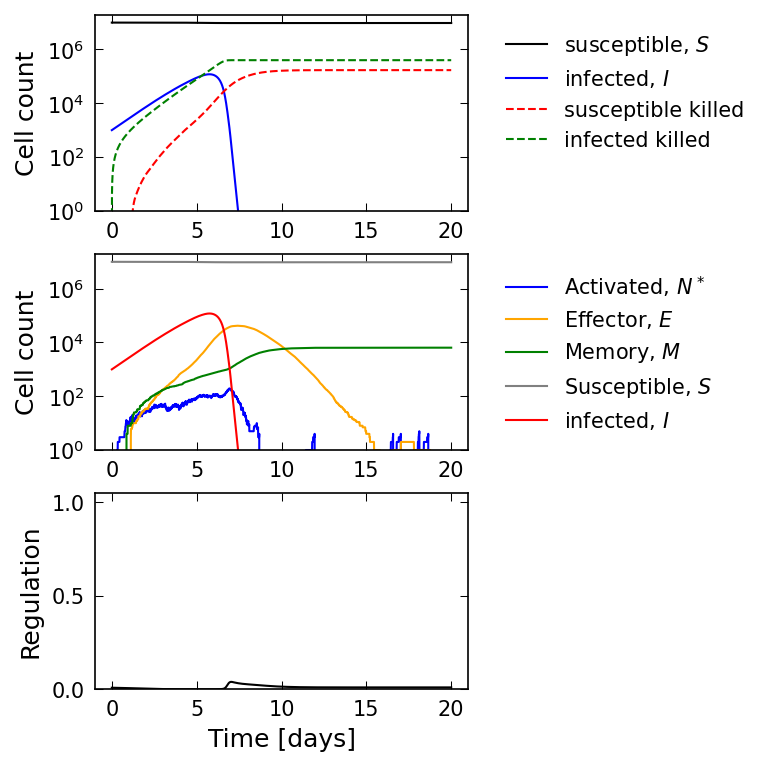

In [7]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(5,5))

ax1.plot(ts, S, 'k', label = r'susceptible, $S$')
ax1.plot(ts, I, 'b', label = r'infected, $I$')

ax1.plot(ts, I_d_S, 'r', linestyle = '--', label = r'susceptible killed')
ax1.plot(ts, I_d_I, 'g', linestyle = '--', label = r'infected killed')
ax1.set(ylabel='Cell count')
ax1.set_ylim(1, S_0*2)
ax1.semilogy()
ax1.minorticks_off()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, Na, 'b', label = r'Activated, $N^*$')
ax2.plot(ts, E, 'orange', label = r'Effector, $E$')
ax2.plot(ts, M, 'g', label = r'Memory, $M$')
ax2.plot(ts, S, 'grey', label = r'Susceptible, $S$')
ax2.plot(ts, I, 'r', label = r'infected, $I$')
ax2.set(ylabel='Cell count')
ax2.semilogy()
ax2.minorticks_off()
ax2.set_ylim(1, S_0*2)
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, f_XtoY_mwc_like(sig_1 = I, sig_2 = HI, sig_3 = HE, 
                             psi_1 = EM_regulation[0], psi_2 = EM_regulation[1], psi_3 = EM_regulation[2], L_0 = EM_regulation[3], 
                             K_1 = K_IE, K_2 = K_EH, K_3 = K_EH),
         'k-', label = r'Regulation, $f(I,H)$')
ax3.set(xlabel=r'Time [days]', ylabel='Regulation')
ax3.minorticks_off()
ax3.set_ylim(0,1.05)

fig.savefig("_figs/"+infection_model+'-'+'virus-effector dynamics-'+reg_string+'.png', dpi=150, bbox_inches="tight")

3.0771760000000006

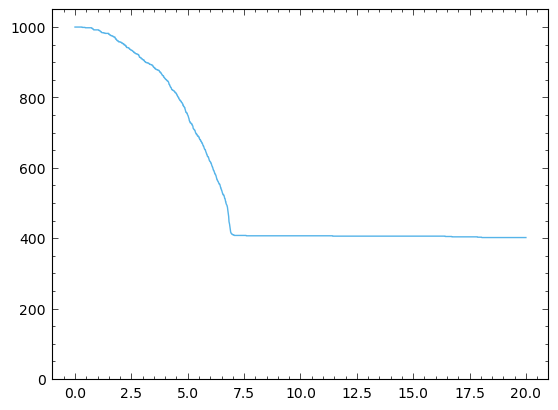

In [8]:
plt.plot(ts, N)
plt.ylim(0, 1.05*N_0)
np.mean(np.argmax(Eff >0 , axis = 0)*(ts[1]-ts[0])*(np.amax(Eff, axis = 0) > 0 ))

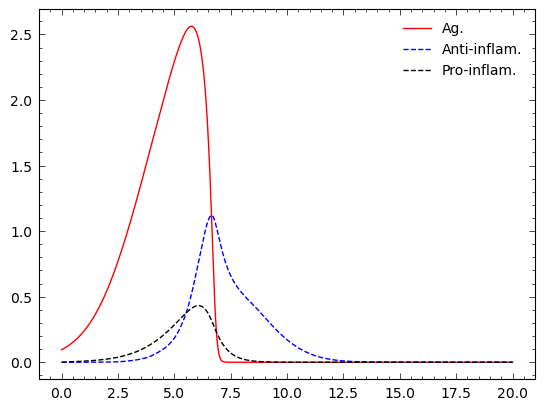

In [9]:
plt.plot(ts, np.log((1 + I/K_IE)), 'r', label = "Ag.")
plt.plot(ts, np.log((1 + HE/K_EH)), 'b--', label = "Anti-inflam.")
plt.plot(ts, np.log((1 + HI/K_EH)), 'k--', label = "Pro-inflam.")
plt.legend()

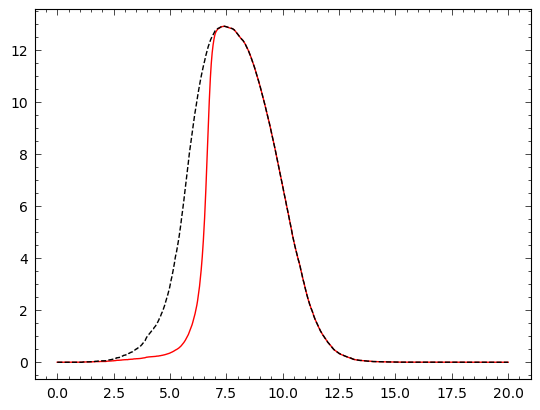

In [10]:
plt.plot(ts,d_IE*E/(K_IE + I + E), 'r')
plt.plot(ts, d_IE*E/(K_IE + E), 'k--')

In [11]:
print(f'Memory fraction = {(sim_summary[8]+sim_summary[10])/sim_summary[5]}')
print(f'Number of memory cells = {np.max(M)}')
print(f'1st infection harm = {sim_summary[3]/(d_S*S_0)}')
print(f'1st response toxicity = {sim_summary[4]/(d_S*S_0)}')
print(f'Minimum susceptible = {np.min(S)/S_0}')

Memory fraction = 0.09594292803970224
Number of memory cells = 6407.0
1st infection harm = 3.9993683333032277
1st response toxicity = 1.7055024481961325
Minimum susceptible = 0.9608353949344812


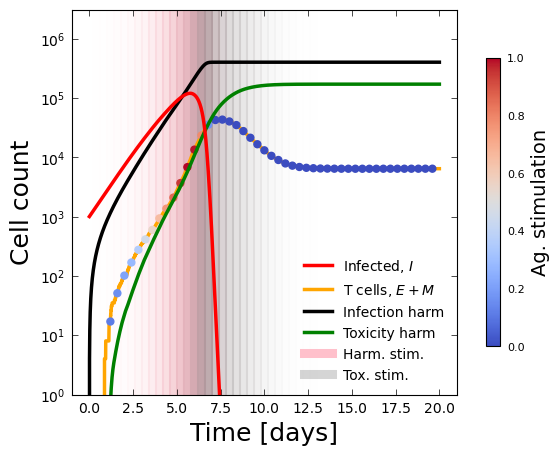

In [12]:
# Plot simulated infection dynamics: pretty plots
pnts = 50
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
sus = S[keep]
naive = Na[keep]
eff = E[keep]
mem = M[keep]
p_load = np.log(1 + I[keep]/K_IE)/np.log(1 + np.max(I[keep])/K_IE) if np.max(I[keep]) > 0 else I[keep]
inflam = np.log((1 + HI[keep]/K_EH))/np.log((1 + np.max(HI[keep])/K_EH))
anti_inflam = np.log((1 + HE[keep]/K_EH))/np.log((1 + np.max(HE[keep])/K_EH)) if np.max(HE[keep]) > 0 else HE[keep]
inf_harm = I_d_I[keep]
toxicity = I_d_S[keep]
time = ts[keep]

fig, ax = plt.subplots(figsize=(7.5,5))

ax.plot(ts, I, 'r', label = r'Infected, $I$', linewidth=2.5)
# ax.plot(ts, S, 'grey', label = r'Susceptible, $S$', linewidth=2.5)

ax.plot(ts, E + M, 'orange', zorder = 1, linewidth=2.5, label = r'T cells, $E + M$')
im = ax.scatter(time, eff+mem, marker ='o', c = p_load, cmap='coolwarm') #, norm=mpl.colors.LogNorm())

ax.plot(ts, I_d_I, 'black', zorder = 1, linewidth=2.5, label = r'Infection harm')
ax.plot(ts, I_d_S, 'green', zorder = 1, linewidth=2.5, label = r'Toxicity harm')
# ax.plot(time, mem, 'k--')
# ax.scatter(time, mem, marker ='s', c = p_load, cmap='coolwarm',
#             label = r'Mem., $M$') #, norm=mpl.colors.LogNorm())

# ax.plot(time, inf_harm, 'r', linewidth = 2.0, label = r'Harm, $\mathcal{H}_I$')

# ax.plot(time, toxicity, 'y', linewidth = 2.0,label = r'Toxicity, $\mathcal{H}_S$')

ax.set_box_aspect(1)
cb = fig.colorbar(im, ax=ax, orientation='vertical', shrink = 0.75, pad = 0.05)
cb.set_label('Ag. stimulation', fontsize = 14)
cb.ax.tick_params(labelsize=8)
ax.set_ylabel('Cell count', fontsize = 18)
ax.set_xlabel(r"Time [days]", fontsize = 18)
ax.semilogy()
ax.minorticks_off()
ax.set_ylim(1,)
# locmaj = mpl.ticker.LogLocator(numticks=4)
# ax.yaxis.set_major_locator(locmaj)

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        ax.axvline(x=time[i], linestyle='-', linewidth=6.5, color='pink', alpha=inflam[i], label =r"Harm. stim.", zorder = 0)
        ax.axvline(x=time[i], linestyle='-', linewidth=6.5, color='grey', alpha=anti_inflam[i]/2, label =r"Tox. stim.", zorder = 0)
    else:
        ax.axvline(x=time[i], linestyle='-', linewidth=6.5, color='pink', alpha=inflam[i], zorder = 0)
        ax.axvline(x=time[i], linestyle='-', linewidth=6.5, color='grey', alpha=anti_inflam[i]/2, zorder = 0)

ax.legend(loc='lower right', fontsize = 10)

plt.savefig('_figs/'+infection_model+'-timeline-of-infection-dynamics-'+reg_string+'.png', dpi=150, bbox_inches="tight")

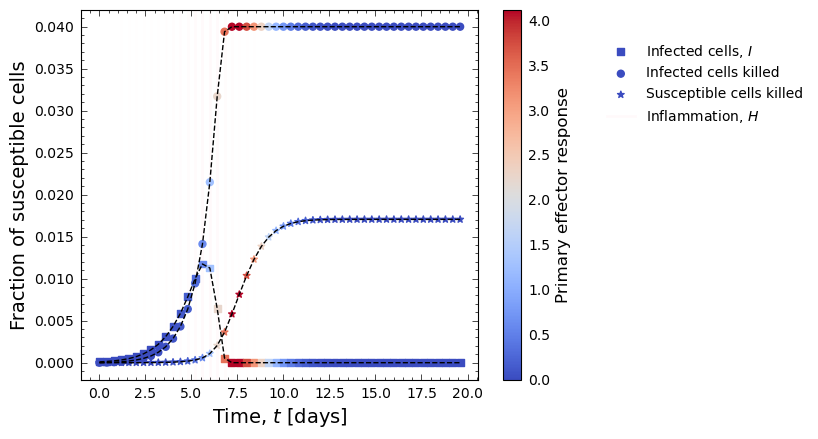

In [13]:
# Plot simulated infection dynamics: pretty plots of harm
pnts = 50
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]

eff = E[keep]
p_load = I[keep]/S_0
sus = S[keep]/S_0
inf_harm = I_d_I[keep]/S_0
inflam_harm = I_d_S[keep]/S_0
inflam = np.log((1 + HI[keep]/K_EH))/np.log((1 + S_0/K_EH))
time = ts[keep]

plt.scatter(time, p_load, marker ='s', c =eff/K_IE, cmap='coolwarm', 
            label = r'Infected cells, $I$') #, norm=mpl.colors.LogNorm())
plt.plot(time, p_load, 'k--')

# plt.scatter(time, sus, marker ='>', c =eff/K_IE, cmap='coolwarm', 
#             label = r'Susceptible cells, $S$') #, norm=mpl.colors.LogNorm())
# plt.plot(time, sus, 'k--')

plt.scatter(time, inf_harm, marker ='o', c =eff/K_IE, cmap='coolwarm', 
            label = 'Infected cells killed')
plt.plot(time, inf_harm, 'k--')

plt.scatter(time, inflam_harm, marker ='*', c =eff/K_IE, cmap='coolwarm',
            label = 'Susceptible cells killed')
plt.plot(time, inflam_harm, 'k--')

plt.colorbar(label = "Primary effector response")
plt.ylabel('Fraction of susceptible cells', fontsize = 14)
plt.xlabel(r"Time, $t$ [days]", fontsize = 14)

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        plt.axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], label =r"Inflammation, $H$", zorder = 0)
    else:
        plt.axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        
plt.legend(loc='center right', bbox_to_anchor=(1.85, 0.8), fontsize = 10)
plt.savefig('_figs/'+infection_model+'-infection-harm-'+reg_string+'.png', dpi=150, bbox_inches="tight")

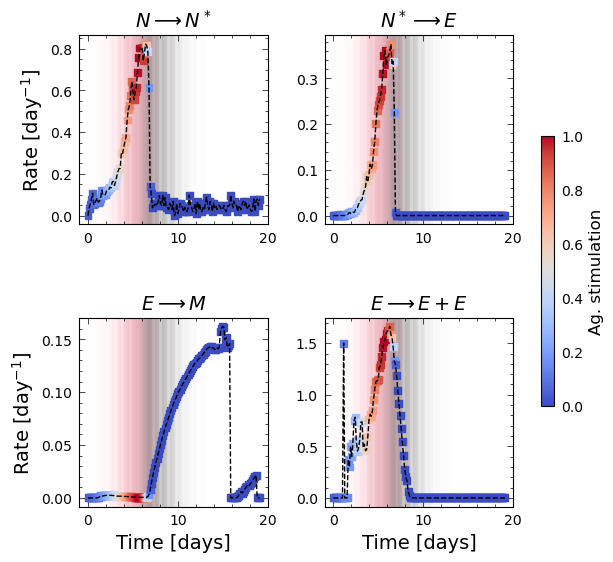

In [14]:
# Plot simulated infection dynamics: pretty plots
pnts = 150
keep = [1 + i*int(len(E)/pnts) for i in np.arange(0,pnts)]
bias_diff = p_diff[keep]
sus = S[keep]
p_load = np.log(1 + I[keep]/K_IE)/np.log(1 + np.max(I[keep])/K_IE) if np.max(I[keep]) > 0 else I[keep]
inflam = np.log((1 + HI[keep]/K_EH))/np.log((1 + np.max(HI[keep])/K_EH))
anti_inflam = np.log((1 + HE[keep]/K_EH))/np.log((1 + np.max(HE[keep])/K_EH)) if np.max(HE[keep]) > 0 else HE[keep]
time = ts[keep]

fig, axs = plt.subplots(2,2, figsize=(7,7))

for i in np.arange(0, len(inflam), 1):
    if i == np.argmax(inflam):
        axs[0,0].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        axs[0,1].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        axs[1,0].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        axs[1,1].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0, label =r"Inflammation, $H$")
        
        axs[0,0].axvline(x=time[i], linestyle='-', linewidth=2.0, color='grey', alpha=anti_inflam[i]/2, zorder = 0)
        axs[0,1].axvline(x=time[i], linestyle='-', linewidth=2.0, color='grey', alpha=anti_inflam[i]/2, zorder = 0)
        axs[1,0].axvline(x=time[i], linestyle='-', linewidth=2.0, color='grey', alpha=anti_inflam[i]/2, zorder = 0)
        axs[1,1].axvline(x=time[i], linestyle='-', linewidth=2.0, color='grey', alpha=anti_inflam[i]/2, zorder = 0, label =r"Anti-inflammation, $P$")
    else:
        axs[0,0].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        axs[0,1].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        axs[1,0].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0)
        axs[1,1].axvline(x=time[i], linestyle='-', linewidth=2.0, color='pink', alpha=inflam[i], zorder = 0, label =r"Inflammation, $H$")
        
        axs[0,0].axvline(x=time[i], linestyle='-', linewidth=2.0, color='grey', alpha=anti_inflam[i]/2, zorder = 0)
        axs[0,1].axvline(x=time[i], linestyle='-', linewidth=2.0, color='grey', alpha=anti_inflam[i]/2, zorder = 0)
        axs[1,0].axvline(x=time[i], linestyle='-', linewidth=2.0, color='grey', alpha=anti_inflam[i]/2, zorder = 0)
        axs[1,1].axvline(x=time[i], linestyle='-', linewidth=2.0, color='grey', alpha=anti_inflam[i]/2, zorder = 0, label =r"Anti-inflammation, $P$")


im1 = axs[0,0].scatter(time, bias_diff[:,0], marker = 's', c =p_load, cmap='coolwarm', 
            label = r'$N \longrightarrow N^*$')
axs[0,0].plot(time, bias_diff[:,0],'k--')
axs[0,0].title.set_text(r'$N \longrightarrow N^*$')
axs[0,0].set_box_aspect(1)

im2 = axs[0,1].scatter(time, bias_diff[:,1], marker = 's', c =p_load, cmap='coolwarm', 
            label = r'$N^* \longrightarrow E$')
axs[0,1].plot(time, bias_diff[:,1],'k--')
axs[0,1].title.set_text(r'$N^* \longrightarrow E$')
axs[0,1].set_box_aspect(1)

im3 = axs[1,0].scatter(time, bias_diff[:,2], marker = 's', c =p_load, cmap='coolwarm', 
            label = r'$E \longrightarrow M$')
axs[1,0].plot(time, bias_diff[:,2],'k--')
axs[1,0].title.set_text(r'$E \longrightarrow M$')
axs[1,0].set_box_aspect(1)

im4 = axs[1,1].scatter(time, bias_diff[:,3], marker = 's', c =p_load, cmap='coolwarm', 
            label = r'$E \longrightarrow M$')
axs[1,1].plot(time, bias_diff[:,3],'k--')
axs[1,1].title.set_text(r'$E \longrightarrow E + E$')
axs[1,1].set_box_aspect(1)

axs[0,0].set_ylabel('Rate [day$^{-1}$]', fontsize = 14)
axs[1,0].set_ylabel('Rate [day$^{-1}$]', fontsize = 14)
axs[1,0].set_xlabel("Time [days]", fontsize = 14)
axs[1,1].set_xlabel("Time [days]", fontsize = 14)

fig.subplots_adjust(wspace=.3, hspace = 0.1)
cb = fig.colorbar(im1, ax=axs, shrink = 0.5, pad = 0.05, orientation='vertical')
cb.set_label('Ag. stimulation')

#cb.set_clim(-0.4,0.4)
    
# plt.colorbar(label =r"pathogen load, $I(t)$")
# plt.ylabel('transition weight', fontsize = 16)
# plt.xlabel("time (days)", fontsize = 16)
# plt.legend() #bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.savefig('_figs/'+infection_model+'-diff-bias-over-time-'+reg_string+'.png', dpi=150, bbox_inches="tight")

### (2) Plot lineage-based trajectories

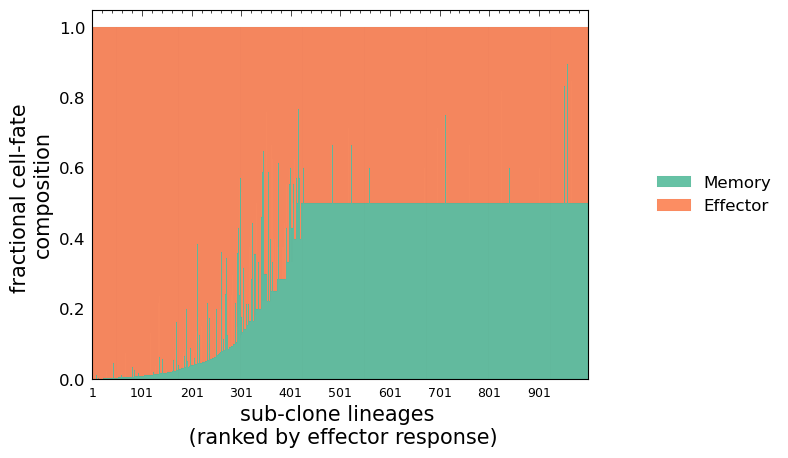

In [15]:
keys = np.array(['Memory', 'Effector'])
all_counts = lin_comp[1:3].T
effector_ranking = np.argsort(all_counts[:, 1])[::-1]
all_counts = all_counts[effector_ranking]
total_counts = all_counts.sum(axis=1)
norm_counts = all_counts / total_counts[:, None]
norm_counts[~np.isfinite(norm_counts)] = 0
comp_argsort = np.argsort(np.max(all_counts, axis=0))
bar_dict = {k: v for k, v in zip(keys[comp_argsort], norm_counts.T[comp_argsort])}
lineage_idxs = np.arange(all_counts.shape[0])

fig, ax = plt.subplots()
bottom = np.zeros(len(lineage_idxs))
cmap_colors = sns.color_palette('Set2', 10)
cmap_colors = [cmap_colors[i]
               for i in [0, 1, 5]]#[7, 2, 0, 1, 5]]
# cmap_colors = [cmap_colors[i]
#                for i in [6, 1, 2, 5, 0]]
width = 1

for i, (celltype, fraction) in enumerate(bar_dict.items()):
    ax.bar(lineage_idxs, fraction, width,
           edgecolor='k', linewidth=0.01,
           label=celltype, bottom=bottom, color=cmap_colors[i])
    bottom += fraction
    
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize = 12)
ax.set_xlim(-0.5, len(all_counts) - 0.5)
ax.set_xlabel('sub-clone lineages \n (ranked by effector response)', fontsize = 15)
ax.set_ylabel('fractional cell-fate \ncomposition', fontsize = 15)
#ax.set_yscale('log')

ax.set_xticks(np.arange(0, Eff.shape[1], int(Eff.shape[1]/10)))
ax.set_xticklabels(1 + np.arange(0, Eff.shape[1], int(Eff.shape[1]/10)), fontsize=9)

ax.set_yticks(np.round(np.arange(0, 1.2, 0.2), 1))
ax.set_yticklabels(ax.get_yticks(), fontsize=12)

fig.savefig("_figs/"+infection_model+'-'+'fates-by-lin-'+reg_string+'.png', dpi=150, bbox_inches="tight")


[]

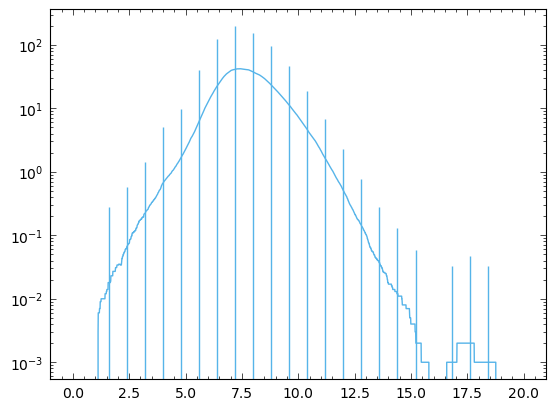

In [16]:
plt.errorbar(ts, np.mean(Eff, axis = 1), yerr = np.std(Eff, axis = 1), errorevery = 100)
plt.semilogy()

0.598


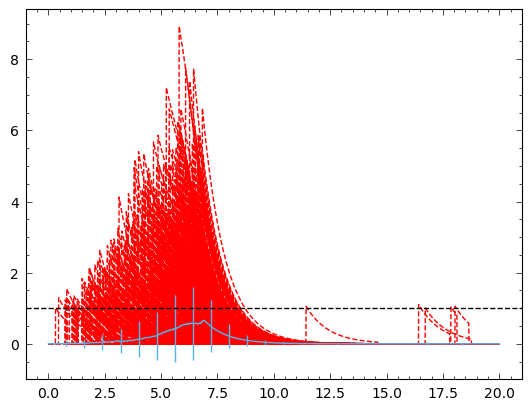

In [17]:
plt.plot(ts, mycE, 'r--')
plt.errorbar(ts, np.mean(mycE, axis = 1), yerr = np.std(mycE, axis = 1), errorevery = 100)
#plt.plot(ts, mycMa, 'k-')
plt.axhline(y = myc_thresh, color = 'k', linestyle = '--')
print(np.sum(np.max(mycE, axis=0) > myc_thresh)/N_0)

Text(0, 0.5, 'Counts')

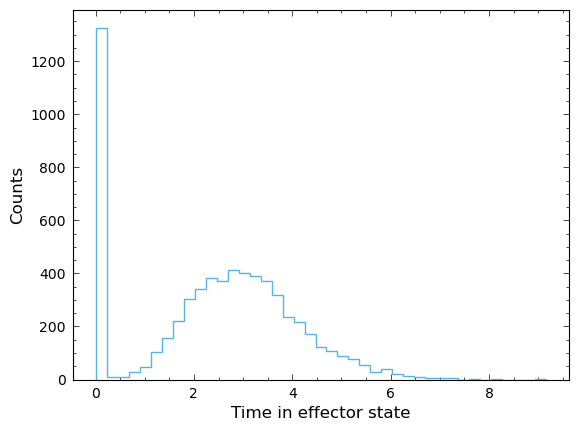

In [18]:
plt.hist(T_pEcytM, bins = 'auto', histtype='step');
plt.xlabel("Time in effector state")
plt.ylabel("Counts")

1.5954763327428598 5.0


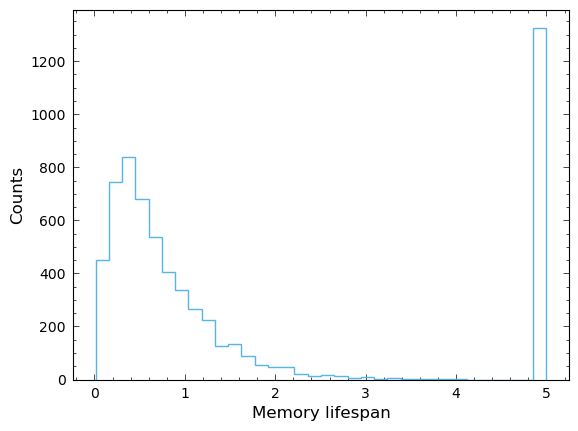

In [19]:
plt.hist(memory_lifespan(T_pEcytM[memory_lifespan(T_pEcytM) > t_E_die])/365.25, bins = 'auto', histtype='step');
plt.xlabel("Memory lifespan")
plt.ylabel("Counts")
print(sim_summary[9], sim_summary[11])

Text(0.5, 0.98, 'Peak response response: $N_0=$ 1000, $d_I=$0.5')

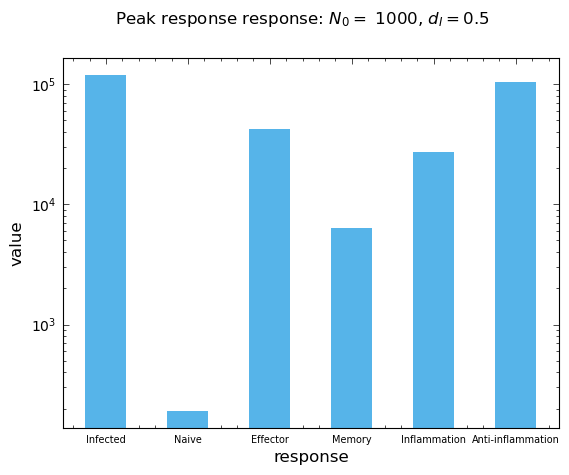

In [20]:
# Compute max values in the data
r = np.arange(6)
width = 0.5
plt.bar(r, np.amax(np.array([I, Na, E, M, HI, HE]).T, axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r, ["Infected","Naive","Effector","Memory", "Inflammation", "Anti-inflammation"], fontsize = 7)

plt.semilogy()
plt.suptitle(r'Peak response response: $N_0=$ '+str(N_0) +r', $d_I=$'+str(d_I))

In [21]:
bias_1 = f_XtoY(I, HI, 
       -2.0, -2.0, 0.0, L_0 = 4*np.log(2), 
       K_I = K_IE, K_H = K_EH)
bias_2 = f_XtoY(I, HI, 
       -2.0, 2.0, 0.0, L_0 = -0*np.log(2), 
       K_I = K_IE, K_H = K_EH)

plt.plot(ts, bias_1, 'r')
plt.plot(ts, bias_2, 'k--')
plt.plot(ts, Na/np.amax(Na))
plt.plot(ts, A/(Na + A))
plt.plot(ts, H**l_H/(K_EH**l_H + H**l_H))

NameError: name 'f_XtoY' is not defined

In [ ]:
d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw/"
comment = "sparse-reg"
infection_model = "acute" # "cancer", "acute"
runs = 5

run(batch = [196.0], outdir=d, comment=comment, infection_model = infection_model, runs = runs, num_cpu = 136, run_time = 4.0)

In [ ]:
d_file = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw/sim_batch_0.0-'+str(runs)+'-'+infection_model+'-'+comment+'.pkl'
with open(d_file, 'rb') as f:   
    out = pickle.load(f)